# Challenge 1 — Exploratory Data Analysis

## Titanic Dataset

Analyze a messy Titanic dataset to determine:

- What is in the data?
- What can we trust?
- What are the three most important findings?

The analysis covers data profiling, cleaning, exploratory visualization, data-quality risks, and actionable insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/train.csv")

print("Dataset Shape:", df.shape)

print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().mean() * 100).round(2))

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (891, 12)

Column Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Value Percentage:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Cleaning

The raw dataset contains missing values and categorical columns stored as object types. The cleaning decisions below are made before exploration so that the analysis is based on a consistent dataset.

In [2]:
# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Handle Age
df["Age"] = df["Age"].fillna(df["Age"].median())
print("Age: Missing values replaced with the median because age is numerical and the median is less affected by extreme values.")

# Handle Embarked
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print("Embarked: Missing values replaced with the mode because it is a categorical variable.")

# Handle Cabin
df["Cabin"] = df["Cabin"].fillna("Unknown")
print("Cabin: Missing values replaced with 'Unknown' because missing cabin information represents an unknown cabin rather than a measurable numerical value.")

# Remove duplicates
df = df.drop_duplicates()
print("Duplicates: Duplicate rows were removed to prevent the same passenger record from being counted more than once.")

# Check data types
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

print("\nUpdated Data Types:")
print(df.dtypes)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nCleaned Shape:", df.shape)

Duplicate Rows: 0
Age: Missing values replaced with the median because age is numerical and the median is less affected by extreme values.
Embarked: Missing values replaced with the mode because it is a categorical variable.
Cabin: Missing values replaced with 'Unknown' because missing cabin information represents an unknown cabin rather than a measurable numerical value.
Duplicates: Duplicate rows were removed to prevent the same passenger record from being counted more than once.

Updated Data Types:
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
dtype: object

Remaining Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare      

## 3. Outlier Detection

Outliers are checked in numerical variables using the IQR method. Extreme values are not automatically removed because some unusual values may represent legitimate passengers or fares.

In [3]:
numeric_columns = ["Age", "Fare", "SibSp", "Parch"]

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}:")
    print(f"  Q1: {q1:.2f}")
    print(f"  Q3: {q3:.2f}")
    print(f"  IQR: {iqr:.2f}")
    print(f"  Potential outliers: {len(outliers)}")
    print(f"  Bounds: {lower_bound:.2f} to {upper_bound:.2f}")
    print()

Age:
  Q1: 22.00
  Q3: 35.00
  IQR: 13.00
  Potential outliers: 66
  Bounds: 2.50 to 54.50

Fare:
  Q1: 7.91
  Q3: 31.00
  IQR: 23.09
  Potential outliers: 116
  Bounds: -26.72 to 65.63

SibSp:
  Q1: 0.00
  Q3: 1.00
  IQR: 1.00
  Potential outliers: 46
  Bounds: -1.50 to 2.50

Parch:
  Q1: 0.00
  Q3: 0.00
  IQR: 0.00
  Potential outliers: 213
  Bounds: 0.00 to 0.00



### Outlier Decision

Potential outliers were identified using the IQR method, but they were not automatically removed. Extreme values such as high fares, older passengers, and larger family groups can represent legitimate observations. The IQR method is also not informative for Parch because both Q1 and Q3 are zero, causing many valid observations to be flagged.

## 4.1 Survival Rate by Passenger Class

**Question:** Did passengers in higher classes have a higher survival rate?

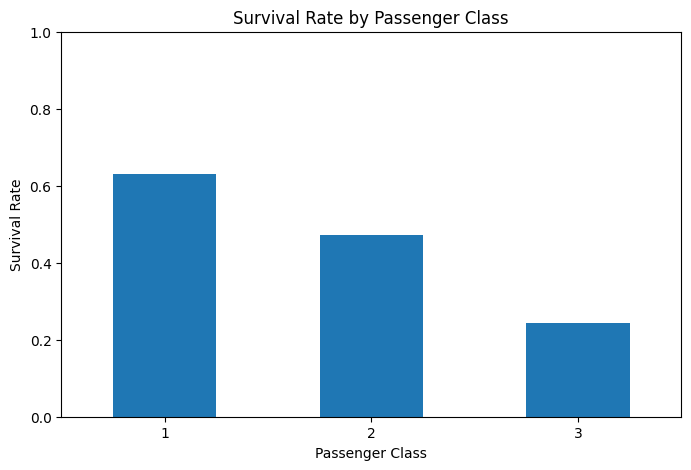

In [4]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(8, 5))
survival_by_class.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

**Observation:** Survival rates differ substantially by passenger class, with first-class passengers having a higher survival rate than passengers in lower classes.

## 4.2 Survival Rate by Sex

**Question:** Was survival different between male and female passengers?

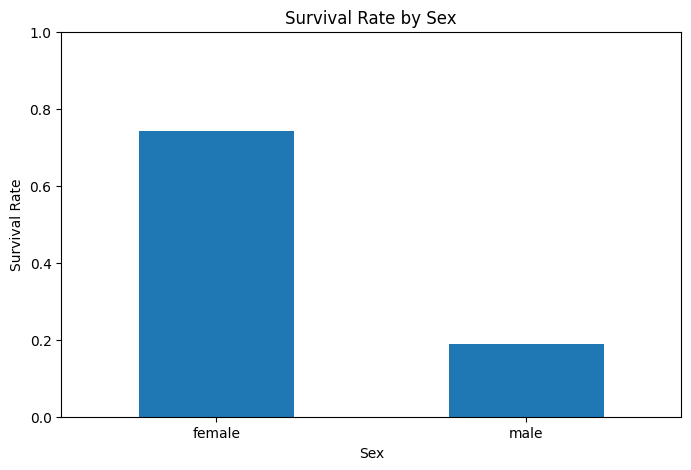

In [5]:
survival_by_sex = df.groupby("Sex", observed=True)["Survived"].mean()

plt.figure(figsize=(8, 5))
survival_by_sex.plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

**Observation:** Female passengers had a substantially higher survival rate than male passengers.

## 4.3 Age Distribution by Survival

**Question:** How does passenger age differ between survivors and non-survivors?

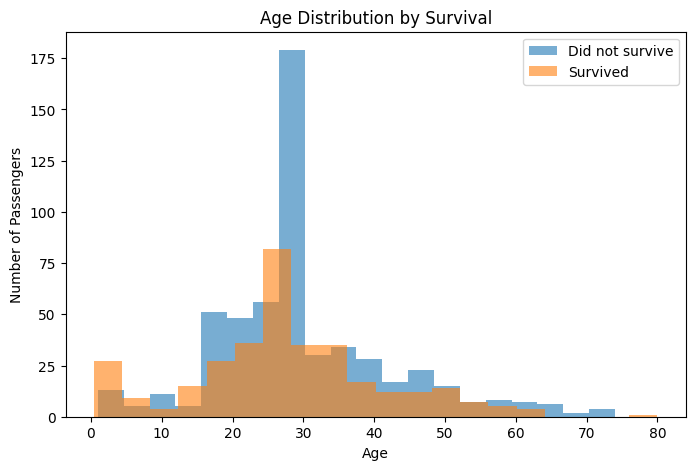

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Survived"] == 0]["Age"],
    bins=20,
    alpha=0.6,
    label="Did not survive"
)

plt.hist(
    df[df["Survived"] == 1]["Age"],
    bins=20,
    alpha=0.6,
    label="Survived"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

**Observation:** Survivors and non-survivors have overlapping age distributions, but the groups do not have identical age profiles.

## 4.4 Fare Distribution by Survival

**Question:** Did passengers who paid higher fares have a different survival outcome?

C:\Users\Manan\AppData\Local\Temp\ipykernel_22900\2374380817.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


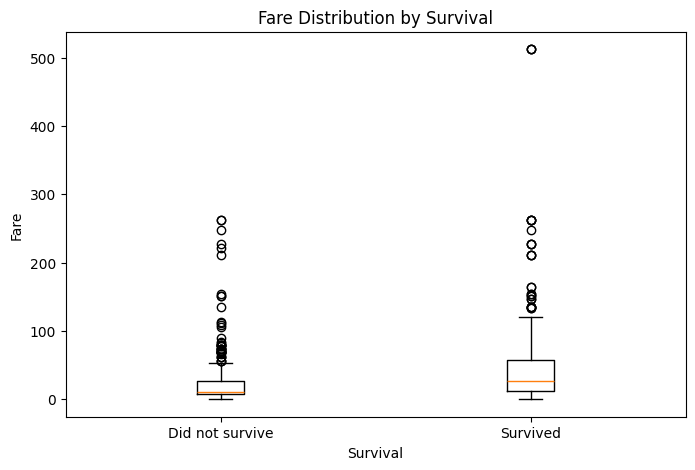

In [7]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Survived"] == 0]["Fare"],
        df[df["Survived"] == 1]["Fare"]
    ],
    labels=["Did not survive", "Survived"]
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survival")
plt.ylabel("Fare")
plt.show()

In [8]:
print("Survival Rate by Sex and Class:")
print(
    df.groupby(["Pclass", "Sex"], observed=True)["Survived"]
    .mean()
    .round(3)
)

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("\nSurvival Rate by Family Size:")
print(
    df.groupby("FamilySize")["Survived"]
    .mean()
    .round(3)
)

Survival Rate by Sex and Class:
Pclass  Sex   
1       female    0.968
        male      0.369
2       female    0.921
        male      0.157
3       female    0.500
        male      0.135
Name: Survived, dtype: float64

Survival Rate by Family Size:
FamilySize
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64


**Observation:** Survivors generally had higher fares, although there is substantial overlap between the two groups.

In [9]:
print("Overall Survival Rate:", df["Survived"].mean())

print("\nSurvival Rate by Class:")
print(df.groupby("Pclass")["Survived"].mean().round(3))

print("\nSurvival Rate by Sex:")
print(df.groupby("Sex", observed=True)["Survived"].mean().round(3))

print("\nMean Fare by Survival:")
print(df.groupby("Survived")["Fare"].mean().round(2))

Overall Survival Rate: 0.3838383838383838

Survival Rate by Class:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

Survival Rate by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Mean Fare by Survival:
Survived
0    22.12
1    48.40
Name: Fare, dtype: float64


## 5. Key Insights

### Insight 1 — Sex and passenger class interact strongly

The survival advantage for female passengers was not uniform across passenger classes. Female survival was 96.8% in first class, 92.1% in second class, and 50.0% in third class. Male survival was much lower across all classes: 36.9%, 15.7%, and 13.5% respectively. This shows that sex and passenger class should be considered together rather than treated as isolated predictors.

### Insight 2 — Medium-sized families had the highest observed survival

Passengers travelling in groups of 2–4 people had substantially higher survival rates than solo travellers or passengers in larger groups. Survival was 55.3% for family size 2, 57.8% for size 3, and 72.4% for size 4, compared with 30.4% for solo travellers. Survival dropped sharply for family sizes of 5 or more. This suggests that travelling with a small family group may have been associated with better survival outcomes, while very large groups had much lower survival.

### Insight 3 — Fare is strongly associated with survival, but overlaps with class

Survivors paid an average fare of 48.40 compared with 22.12 for passengers who did not survive. Combined with the strong class-survival relationship, this suggests that fare is partly capturing differences associated with passenger class rather than representing an independent causal effect. Using both variables in a model could therefore provide overlapping information.

## Data-Quality / Modeling Risk

### Cabin Missingness

The Cabin column contains substantial missing information. Missing values were replaced with "Unknown" to preserve the passenger records, but the missingness itself may contain information. A model could therefore learn from the pattern of missing cabin records rather than from actual cabin information.

### Related Features

Pclass, Fare, and Cabin information are related signals. A model may assign importance to several variables that represent similar underlying differences between passengers. These associations should therefore be interpreted carefully and should not be treated as evidence of causation.

In [10]:
print("Final Dataset Shape:", df.shape)

print("\nFinal Missing Values:")
print(df.isnull().sum())

print("\nFinal Data Types:")
print(df.dtypes)

print("\nDuplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (891, 13)

Final Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
FamilySize     0
dtype: int64

Final Data Types:
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
FamilySize        int64
dtype: object

Duplicate Rows: 0


## 6. Final Validation

The cleaned dataset contains no missing values or duplicate rows. Numerical and categorical columns have appropriate data types, while potential outliers were retained when they could represent legitimate passenger observations.